C:\Users\sahad2\AppData\Local\Temp\ipykernel_24868\2254879088.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_24868\2254879088.py:99: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx


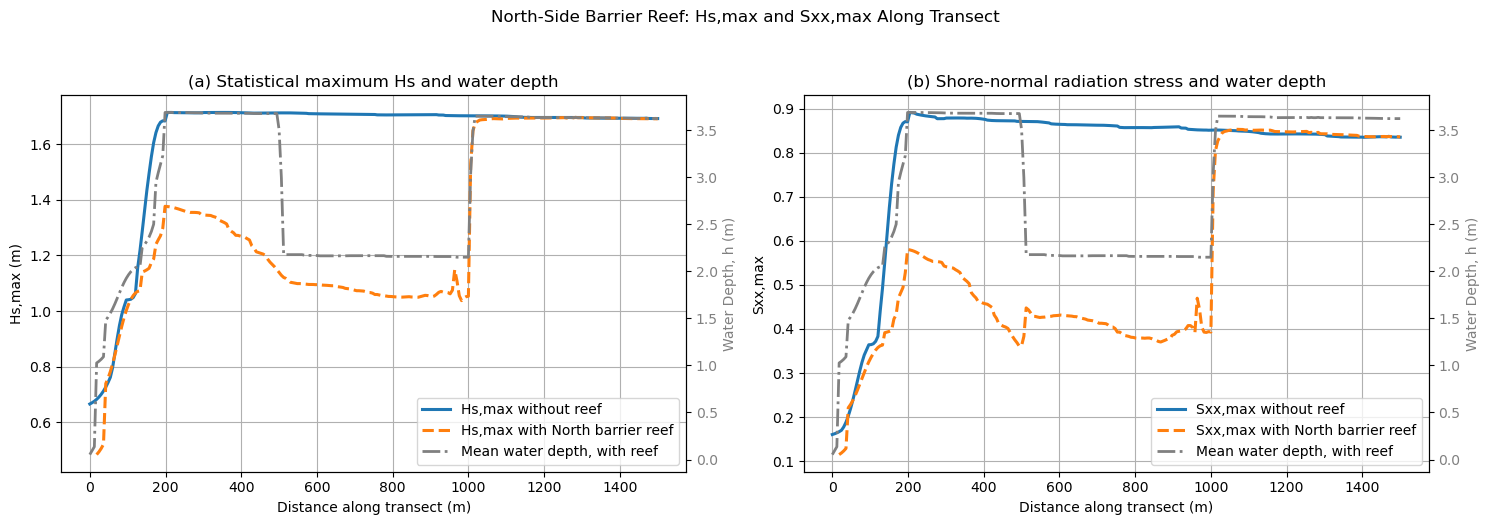

In [8]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Sxxmax_without_reef": sxxmax_no_reef,
    "Sxxmax_with_reef": sxxmax_reef,
    "Mean_water_depth_with_reef_m": depth_reef_mean
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_hs.set_title("(a) Statistical maximum Hs and water depth")

ax_sxx.plot(distance, sxxmax_no_reef, linewidth=2.2, label="Sxx,max without reef")
ax_sxx.plot(distance, sxxmax_reef, linewidth=2.2, linestyle="--", label="Sxx,max with North barrier reef")

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()
ax_sxx_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()
ax_sxx.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx


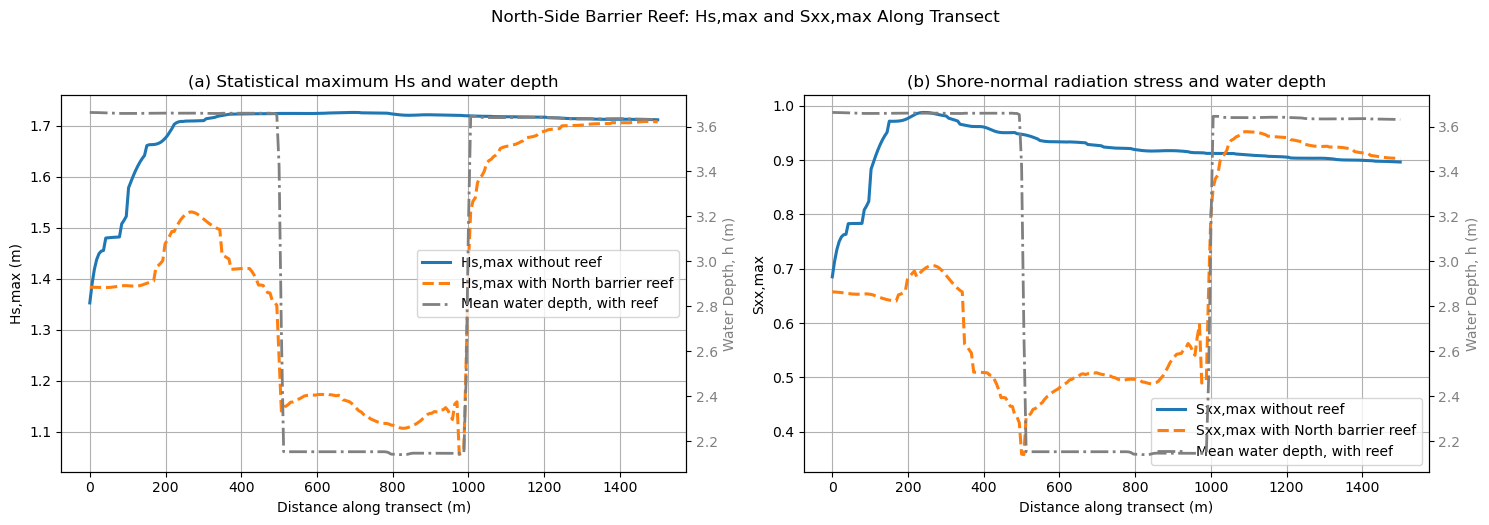

In [10]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx"
# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473


n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Sxxmax_without_reef": sxxmax_no_reef,
    "Sxxmax_with_reef": sxxmax_reef,
    "Mean_water_depth_with_reef_m": depth_reef_mean
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_hs.set_title("(a) Statistical maximum Hs and water depth")

ax_sxx.plot(distance, sxxmax_no_reef, linewidth=2.2, label="Sxx,max without reef")
ax_sxx.plot(distance, sxxmax_reef, linewidth=2.2, linestyle="--", label="Sxx,max with North barrier reef")

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()
ax_sxx_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()
ax_sxx.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx


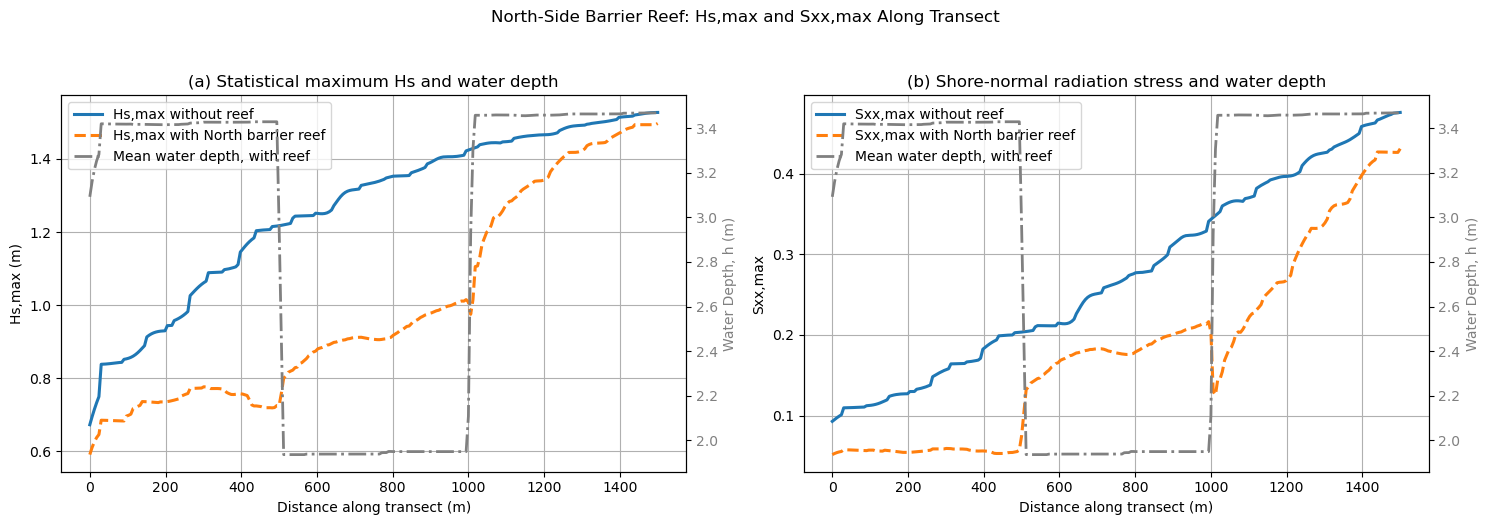

In [12]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_transect_plot_data.xlsx"
# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252



n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Sxxmax_without_reef": sxxmax_no_reef,
    "Sxxmax_with_reef": sxxmax_reef,
    "Mean_water_depth_with_reef_m": depth_reef_mean
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_hs.set_title("(a) Statistical maximum Hs and water depth")

ax_sxx.plot(distance, sxxmax_no_reef, linewidth=2.2, label="Sxx,max without reef")
ax_sxx.plot(distance, sxxmax_reef, linewidth=2.2, linestyle="--", label="Sxx,max with North barrier reef")

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()
ax_sxx_depth.plot(distance, depth_reef_mean, color="gray", linewidth=2, linestyle="-.", label="Mean water depth, with reef")
ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()
ax_sxx.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_wave_power_timeseries.xlsx


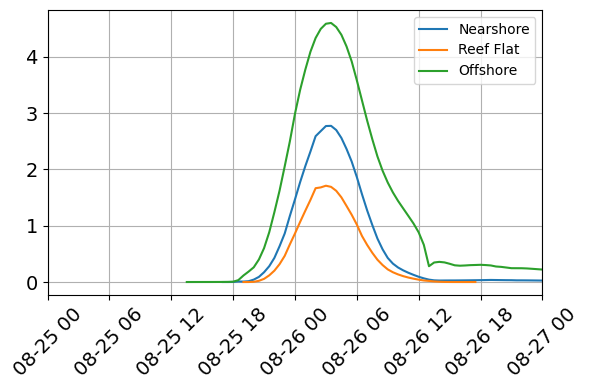

In [4]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Excel output path
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_wave_power_timeseries.xlsx"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

target_coords = {
    "Nearshore": (732244, 3178728),
    "Reef Flat": (732448, 3178266),
    "Offshore": (732650, 3177820)
}

elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

nearest_elements = {}
nearest_distances = {}

for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)
    nearest_distances[loc] = distances[nearest_elements[loc]]

wave_power_data = ds.read(items=["Wave power, p"])
time = np.array(ds.time)

start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

time_indices = np.where((time >= start_time) & (time <= end_time))[0]

wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# =========================
# Export data to Excel
# =========================

df_timeseries = pd.DataFrame({
    "Time": time[time_indices]
})

for loc, series in wave_power_series.items():
    df_timeseries[f"Wave_power_{loc}_kW_per_m"] = series

df_points = pd.DataFrame({
    "Location": list(target_coords.keys()),
    "Target_Easting_m": [target_coords[k][0] for k in target_coords],
    "Target_Northing_m": [target_coords[k][1] for k in target_coords],
    "Nearest_Element_ID": [nearest_elements[k] for k in target_coords],
    "Nearest_Element_Distance_m": [nearest_distances[k] for k in target_coords]
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_timeseries.to_excel(writer, sheet_name="Wave_Power_TimeSeries", index=False)
    df_points.to_excel(writer, sheet_name="Extraction_Points", index=False)

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

tick_size = 14

plt.figure(figsize=(6, 4))

for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.tick_params(axis='both', labelsize=tick_size)

plt.grid()
plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_wave_power_timeseries.xlsx


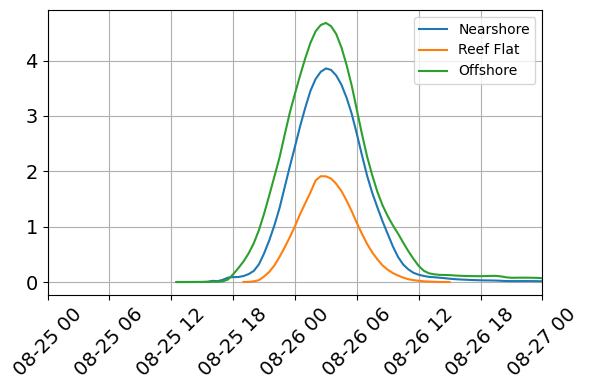

In [5]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Excel output path
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_wave_power_timeseries.xlsx"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (730601, 3174580),
    "Reef Flat": (730961, 3174951),
    "Offshore": (731316, 3175304)
}

elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

nearest_elements = {}
nearest_distances = {}

for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)
    nearest_distances[loc] = distances[nearest_elements[loc]]

wave_power_data = ds.read(items=["Wave power, p"])
time = np.array(ds.time)

start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

time_indices = np.where((time >= start_time) & (time <= end_time))[0]

wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# =========================
# Export data to Excel
# =========================

df_timeseries = pd.DataFrame({
    "Time": time[time_indices]
})

for loc, series in wave_power_series.items():
    df_timeseries[f"Wave_power_{loc}_kW_per_m"] = series

df_points = pd.DataFrame({
    "Location": list(target_coords.keys()),
    "Target_Easting_m": [target_coords[k][0] for k in target_coords],
    "Target_Northing_m": [target_coords[k][1] for k in target_coords],
    "Nearest_Element_ID": [nearest_elements[k] for k in target_coords],
    "Nearest_Element_Distance_m": [nearest_distances[k] for k in target_coords]
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_timeseries.to_excel(writer, sheet_name="Wave_Power_TimeSeries", index=False)
    df_points.to_excel(writer, sheet_name="Extraction_Points", index=False)

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

tick_size = 14

plt.figure(figsize=(6, 4))

for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.tick_params(axis='both', labelsize=tick_size)

plt.grid()
plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_wave_power_timeseries.xlsx


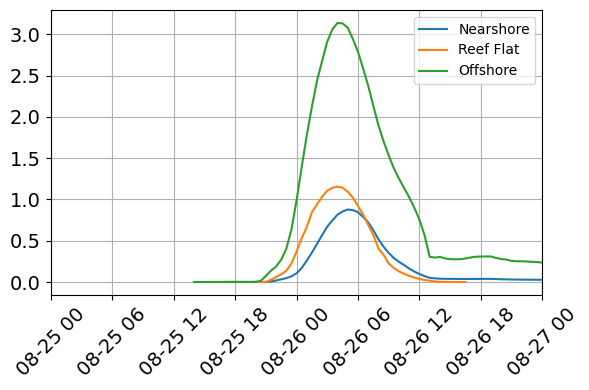

In [6]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File path
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Excel output path
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_wave_power_timeseries.xlsx"

# Load DFSU file
ds = mikeio.Dfsu(dfsu_path)

# Define target points (x, y coordinates)
target_coords = {
    "Nearshore": (736397, 3177672),
    "Reef Flat": (735938, 3177515),
    "Offshore": (735481, 3177360)
}
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

nearest_elements = {}
nearest_distances = {}

for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)
    nearest_distances[loc] = distances[nearest_elements[loc]]

wave_power_data = ds.read(items=["Wave power, p"])
time = np.array(ds.time)

start_time = np.datetime64("2017-08-25T00:00")
end_time = np.datetime64("2017-08-27T00:00")

time_indices = np.where((time >= start_time) & (time <= end_time))[0]

wave_power_series = {
    loc: wave_power_data[0].values[time_indices, idx]
    for loc, idx in nearest_elements.items()
}

# =========================
# Export data to Excel
# =========================

df_timeseries = pd.DataFrame({
    "Time": time[time_indices]
})

for loc, series in wave_power_series.items():
    df_timeseries[f"Wave_power_{loc}_kW_per_m"] = series

df_points = pd.DataFrame({
    "Location": list(target_coords.keys()),
    "Target_Easting_m": [target_coords[k][0] for k in target_coords],
    "Target_Northing_m": [target_coords[k][1] for k in target_coords],
    "Nearest_Element_ID": [nearest_elements[k] for k in target_coords],
    "Nearest_Element_Distance_m": [nearest_distances[k] for k in target_coords]
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_timeseries.to_excel(writer, sheet_name="Wave_Power_TimeSeries", index=False)
    df_points.to_excel(writer, sheet_name="Extraction_Points", index=False)

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

tick_size = 14

plt.figure(figsize=(6, 4))

for loc, power_series in wave_power_series.items():
    plt.plot(time[time_indices], power_series, label=loc)

plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)
plt.tick_params(axis='both', labelsize=tick_size)

plt.grid()
plt.tight_layout()
plt.show()

In [7]:
import mikeio
import numpy as np
import pandas as pd

# =========================
# File path: No-reef condition
# =========================
dfsu_path = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\no_reef_Hs_Tp_timeseries.xlsx"

# =========================
# Target points
# =========================
target_coords = {
    "Point_1": (732186.4519, 3178822.697),
    "Point_2": (730301.6944, 3174532.603),
    "Point_3": (736705.0369, 3177806.705)
}

# =========================
# Load DFSU
# =========================
ds = mikeio.Dfsu(dfsu_path)

elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element for each target point
nearest_elements = {}
nearest_distances = {}

for loc, (x, y) in target_coords.items():
    distances = np.linalg.norm(elem_coords - np.array([x, y]), axis=1)
    nearest_elements[loc] = np.argmin(distances)
    nearest_distances[loc] = distances[nearest_elements[loc]]

# =========================
# Read Hs and Peak Wave Period
# =========================
data = ds.read(items=["Sign. Wave Height", "Peak Wave Period"])

hs = data["Sign. Wave Height"].to_numpy()
tp = data["Peak Wave Period"].to_numpy()

time = np.array(ds.time)

# =========================
# Create time-series dataframe
# =========================
df_ts = pd.DataFrame({
    "Time": time
})

for loc, idx in nearest_elements.items():
    df_ts[f"Hs_{loc}_m"] = hs[:, idx]
    df_ts[f"Peak_Wave_Period_{loc}_s"] = tp[:, idx]

# =========================
# Create point information dataframe
# =========================
df_points = pd.DataFrame({
    "Location": list(target_coords.keys()),
    "Target_Easting_m": [target_coords[k][0] for k in target_coords],
    "Target_Northing_m": [target_coords[k][1] for k in target_coords],
    "Nearest_Element_ID": [nearest_elements[k] for k in target_coords],
    "Nearest_Element_Easting_m": [elem_coords[nearest_elements[k], 0] for k in target_coords],
    "Nearest_Element_Northing_m": [elem_coords[nearest_elements[k], 1] for k in target_coords],
    "Distance_to_Nearest_Element_m": [nearest_distances[k] for k in target_coords]
})

# =========================
# Export to Excel
# =========================
with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_ts.to_excel(writer, sheet_name="Hs_Tp_TimeSeries", index=False)
    df_points.to_excel(writer, sheet_name="Extraction_Points", index=False)

print("Excel file saved successfully:")
print(excel_out)

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\no_reef_Hs_Tp_timeseries.xlsx


C:\Users\sahad2\AppData\Local\Temp\ipykernel_24868\1643124868.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_24868\1643124868.py:99: RuntimeWarning: All-NaN slice encountered
  wpmax_reef = np.nanmax(wp_reef_all, axis=0)


Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_wave_power_transect_plot_data.xlsx


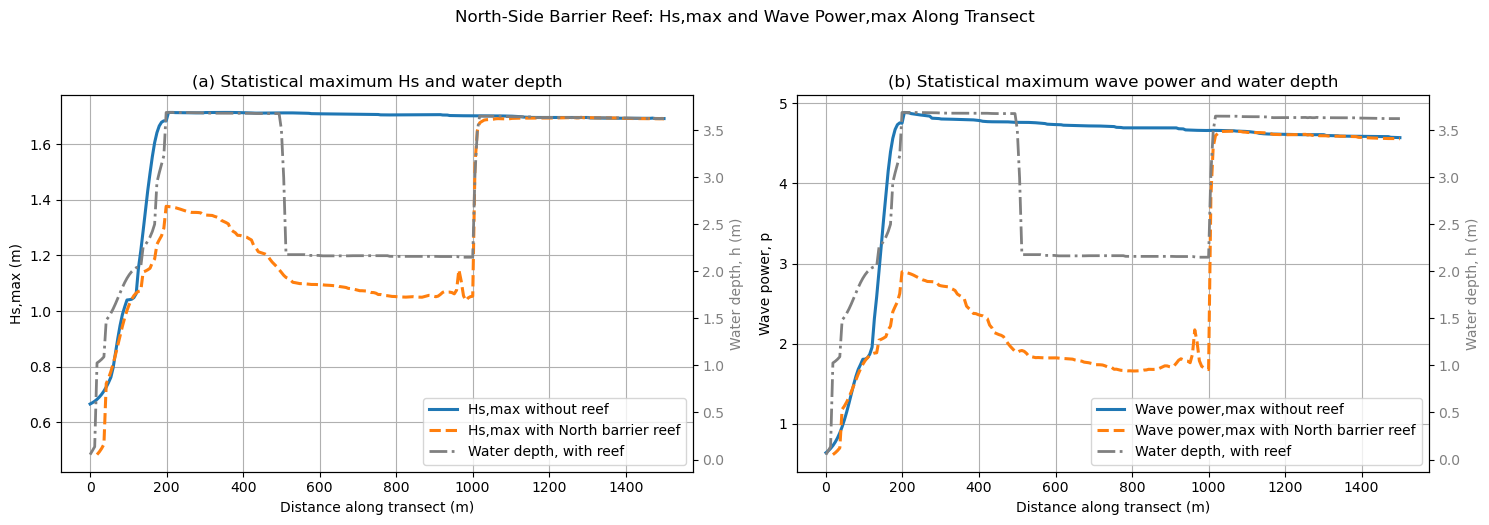

In [13]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\north_barrier_wave_power_transect_plot_data.xlsx"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

wp_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Wave power, p"
)

wp_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Wave power, p"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

wpmax_reef = np.nanmax(wp_reef_all, axis=0)
wpmax_no_reef = np.nanmax(wp_no_reef_all, axis=0)

depth_reef_max = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Wave_power_max_without_reef": wpmax_no_reef,
    "Wave_power_max_with_reef": wpmax_reef,
    "Water_depth_max_with_reef_m": depth_reef_max
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_wp) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------- Hs plot --------
ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_hs_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------- Wave power plot --------
ax_wp.plot(distance, wpmax_no_reef, linewidth=2.2, label="Wave power,max without reef")
ax_wp.plot(distance, wpmax_reef, linewidth=2.2, linestyle="--", label="Wave power,max with North barrier reef")

ax_wp.set_xlabel("Distance along transect (m)")
ax_wp.set_ylabel("Wave power, p")
ax_wp.grid(True)

ax_wp_depth = ax_wp.twinx()
ax_wp_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_wp_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_wp_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_wp.get_legend_handles_labels()
lines2, labels2 = ax_wp_depth.get_legend_handles_labels()
ax_wp.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_wp.set_title("(b) Statistical maximum wave power and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Wave Power,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_barrier_transect_plot_data.xlsx


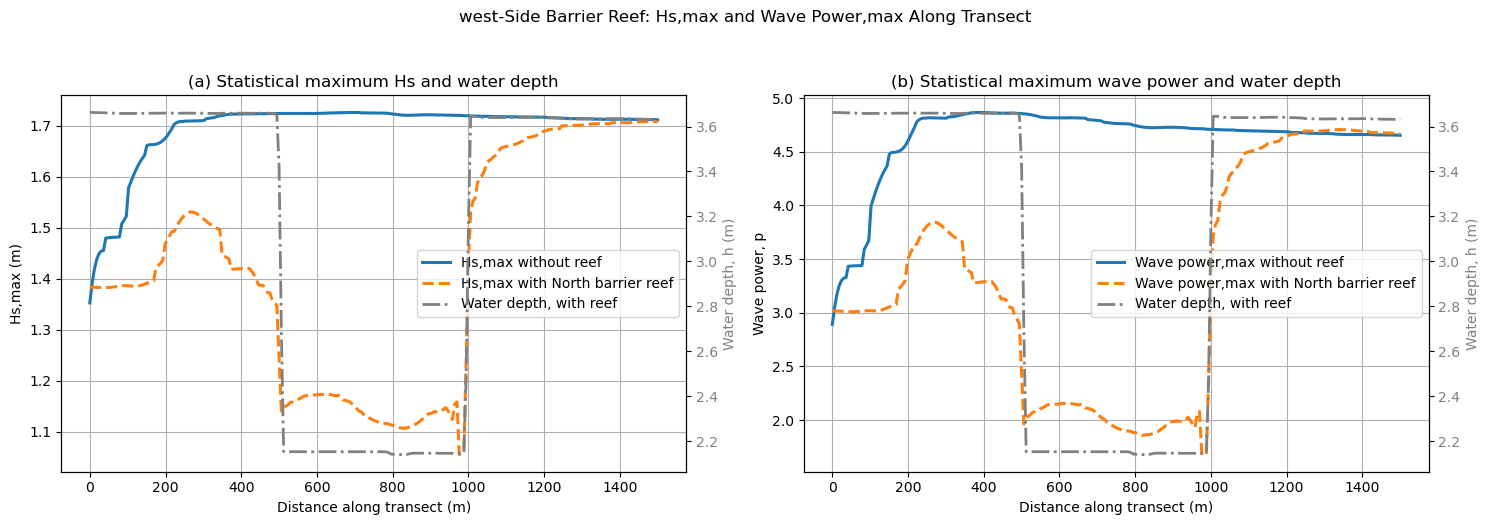

In [14]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_barrier_transect_plot_data.xlsx"
# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473


n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

wp_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Wave power, p"
)

wp_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Wave power, p"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

wpmax_reef = np.nanmax(wp_reef_all, axis=0)
wpmax_no_reef = np.nanmax(wp_no_reef_all, axis=0)

depth_reef_max = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Wave_power_max_without_reef": wpmax_no_reef,
    "Wave_power_max_with_reef": wpmax_reef,
    "Water_depth_max_with_reef_m": depth_reef_max
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_wp) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------- Hs plot --------
ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_hs_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------- Wave power plot --------
ax_wp.plot(distance, wpmax_no_reef, linewidth=2.2, label="Wave power,max without reef")
ax_wp.plot(distance, wpmax_reef, linewidth=2.2, linestyle="--", label="Wave power,max with North barrier reef")

ax_wp.set_xlabel("Distance along transect (m)")
ax_wp.set_ylabel("Wave power, p")
ax_wp.grid(True)

ax_wp_depth = ax_wp.twinx()
ax_wp_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_wp_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_wp_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_wp.get_legend_handles_labels()
lines2, labels2 = ax_wp_depth.get_legend_handles_labels()
ax_wp.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_wp.set_title("(b) Statistical maximum wave power and water depth")

plt.suptitle(
    "west-Side Barrier Reef: Hs,max and Wave Power,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_barrier_transect_plot_data.xlsx


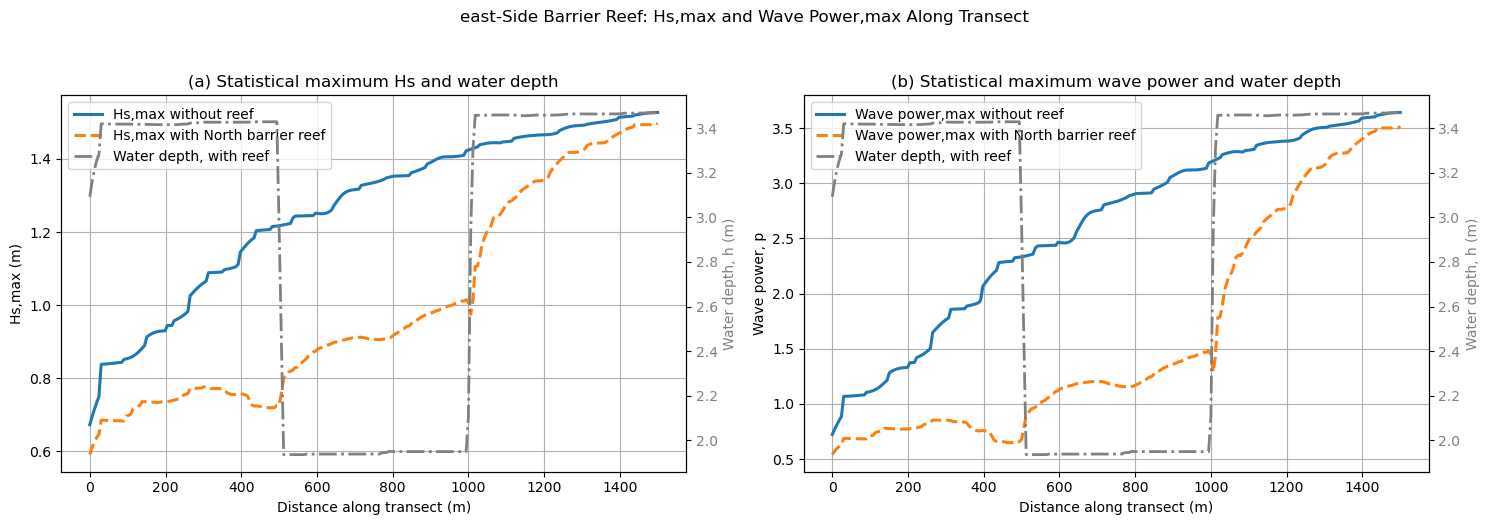

In [16]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_barrier_transect_plot_data.xlsx"
# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252


n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

wp_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Wave power, p"
)

wp_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Wave power, p"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

wpmax_reef = np.nanmax(wp_reef_all, axis=0)
wpmax_no_reef = np.nanmax(wp_no_reef_all, axis=0)

depth_reef_max = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Wave_power_max_without_reef": wpmax_no_reef,
    "Wave_power_max_with_reef": wpmax_reef,
    "Water_depth_max_with_reef_m": depth_reef_max
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_wp) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------- Hs plot --------
ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_hs_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------- Wave power plot --------
ax_wp.plot(distance, wpmax_no_reef, linewidth=2.2, label="Wave power,max without reef")
ax_wp.plot(distance, wpmax_reef, linewidth=2.2, linestyle="--", label="Wave power,max with North barrier reef")

ax_wp.set_xlabel("Distance along transect (m)")
ax_wp.set_ylabel("Wave power, p")
ax_wp.grid(True)

ax_wp_depth = ax_wp.twinx()
ax_wp_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_wp_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_wp_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_wp.get_legend_handles_labels()
lines2, labels2 = ax_wp_depth.get_legend_handles_labels()
ax_wp.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_wp.set_title("(b) Statistical maximum wave power and water depth")

plt.suptitle(
    "east-Side Barrier Reef: Hs,max and Wave Power,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Excel file saved successfully:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_Fringing_transect_plot_data.xlsx


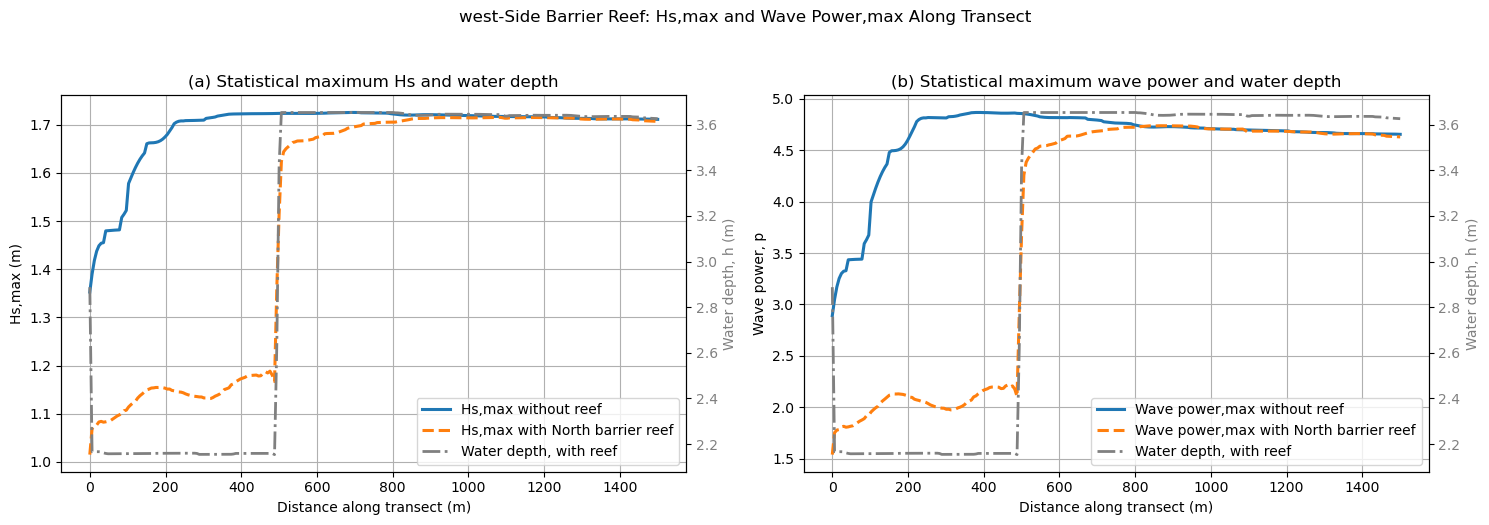

In [17]:
import mikeio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"
excel_out = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\west_Fringing_transect_plot_data.xlsx"
# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473


n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Function
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values

# =========================
# Extract profiles
# =========================

hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

wp_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Wave power, p"
)

wp_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Wave power, p"
)

depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

wpmax_reef = np.nanmax(wp_reef_all, axis=0)
wpmax_no_reef = np.nanmax(wp_no_reef_all, axis=0)

depth_reef_max = np.nanmax(depth_reef_all, axis=0)

# =========================
# Export plot data to Excel
# =========================

df_plot = pd.DataFrame({
    "Distance_along_transect_m": distance,
    "Easting_m": x_line,
    "Northing_m": y_line,
    "Hsmax_without_reef_m": hsmax_no_reef,
    "Hsmax_with_reef_m": hsmax_reef,
    "Wave_power_max_without_reef": wpmax_no_reef,
    "Wave_power_max_with_reef": wpmax_reef,
    "Water_depth_max_with_reef_m": depth_reef_max
})

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_plot.to_excel(
        writer,
        sheet_name="Transect_Plot_Data",
        index=False
    )

print("Excel file saved successfully:")
print(excel_out)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_wp) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------- Hs plot --------
ax_hs.plot(distance, hsmax_no_reef, linewidth=2.2, label="Hs,max without reef")
ax_hs.plot(distance, hsmax_reef, linewidth=2.2, linestyle="--", label="Hs,max with North barrier reef")

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()
ax_hs_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_hs_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()
ax_hs.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------- Wave power plot --------
ax_wp.plot(distance, wpmax_no_reef, linewidth=2.2, label="Wave power,max without reef")
ax_wp.plot(distance, wpmax_reef, linewidth=2.2, linestyle="--", label="Wave power,max with North barrier reef")

ax_wp.set_xlabel("Distance along transect (m)")
ax_wp.set_ylabel("Wave power, p")
ax_wp.grid(True)

ax_wp_depth = ax_wp.twinx()
ax_wp_depth.plot(
    distance,
    depth_reef_max,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth, with reef"
)
ax_wp_depth.set_ylabel("Water depth, h (m)", color="gray")
ax_wp_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_wp.get_legend_handles_labels()
lines2, labels2 = ax_wp_depth.get_legend_handles_labels()
ax_wp.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax_wp.set_title("(b) Statistical maximum wave power and water depth")

plt.suptitle(
    "west-Side Barrier Reef: Hs,max and Wave Power,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()